In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pyplot
import seaborn as sns
import csv

In [19]:
import pandas as pd

# Read using standard pandas (without ignoring errors)
train = pd.read_csv('fraudTrain.csv')


# Drop the extra index column if present
if 'Unnamed: 0' in train.columns:
    train = train.drop(columns=['Unnamed: 0'])


print("Train shape:", train.shape)  # Should show (1296675, 22 or 23)


Train shape: (1296675, 22)


In [46]:
test = pd.read_csv('fraudTest.csv')
# Drop the extra index column if present
if 'Unnamed: 0' in train.columns:
    test = test.drop(columns=['Unnamed: 0'])


print("Test shape:", test.shape)  # Should show (1296675, 22 or 23)

Test shape: (555719, 23)


The Backend Story of the Data
This dataset represents a digital transaction log containing information split across three core entities:

`Cardholder (The Victim):`

The legitimate owner of the credit card account.

Columns: cc_num, first, last, gender, job, dob, street, city, state, zip, lat, long, city_pop.

Role: Represents the cardholder's regular demographic and geographical footprint (who they are, where they live, their age derived from dob, gender, and local city population). They are the victim of the fraud event, not the perpetrator.

`Merchant (The Store / Business)`:

The seller or business terminal where the card money is spent.

Columns: merchant, category, merch_lat, merch_long.

Role: Represents the store name, store category (e.g., grocery, online shopping, entertainment), and store GPS location. Comparing the merchant location against the cardholder's home coordinates helps measure geographical travel anomalies.

`Fraudster (The Hidden Criminal):`

Has no direct profile data or dedicated columns in the dataset.

Role: Their presence is inferred purely through suspicious transactional patterns:

Using a credit card (cc_num) at a merchant location (merch_lat, merch_long) far away from the cardholder's home (lat, long).

Making unusual low-value test transactions or sudden $999+ spike purchases.

Initiating transactions at anomalous hours (e.g., 3:00 AM).

### 1. Cardholder Features

* **`cc_num`**: 16-digit credit card number. Used to aggregate transaction counts and spending frequency for a specific account.
* **`first`**: First name of the cardholder.
* **`last`**: Last name of the cardholder.
* **`gender`**: Biological sex of the cardholder (`M` / `F`). Helps analyze spending patterns across demographic segments.
* **`job`**: Cardholder's occupation. Useful for spending limit profiling.
* **`dob`**: Cardholder's Date of Birth. Used to compute customer **Age**.
* **`street`, `city`, `state`, `zip**`: Cardholder's physical billing address.
* **`city_pop`**: Population size of the cardholder's city. Useful as fraud rates vary between rural and urban areas.
* **`lat`, `long**`: GPS coordinates (Latitude & Longitude) of the cardholder's home.

### 2. Merchant Features

* **`merchant`**: The specific business/terminal receiving the payment. *(Note: The `fraud_` prefix in merchant names is a dataset generator naming artifact, not a flag that the merchant is a criminal entity).*
* **`category`**: Type of merchant business (e.g., `grocery_pos`, `shopping_net`, `entertainment`).
* **`merch_lat`, `merch_long**`: GPS coordinates (Latitude & Longitude) of the merchant terminal. Used to calculate distance from the cardholder's home.

### 3. Transaction Details

* **`trans_date_trans_time`**: Exact date and timestamp of the purchase. Used to check if transactions occur at unusual times (e.g., 3:00 AM).
* **`amt`**: Transaction amount in USD. Key signal for identifying unusual spending or test charges.
* **`trans_num`**: Unique transaction/receipt ID.
* **`unix_time`**: Timestamp converted into Unix epoch seconds. Used to calculate elapsed time between consecutive purchases on the same card.

### 4. Target Variable

* **`is_fraud`**: Target classification label.
* **`0`**: Legitimate transaction made by the real cardholder.
* **`1`**: Fraudulent transaction executed by an unauthorized fraudster.

`preprocessing error `

- dirty data
   - drop unrequired column
     - column00
     - first
     - last
     - trans_num
     - unix time
    - `merchant and    category and job `clean string
    - drop ` street and city` as state give same info
  
    - `zip` has inconsistency issue different digits and convert to string as some has 0 in start and int drop this 0 so convert to string
    - `dob` has null value written of #### instead use NAN




- messy  data    
  - `trans datte and trans time` should be in separate column



---
`preprocesing error :`

  - `feature contruction and extraction:`
     - `dob` calculate age by subtracting dob from trans date and time
     - calculate `distance` between merchant and cardholder using gps coordinates
     - `time & date & day or night ` extract from time date column

     - extract the amount of current transaction to the average of previous transaction

     - calculate transaction made by every cc_num

  - `feature scaling `
     - standarize  the
        - use log transformer before scaling amount column
        - age after calculating
        - distance number
        - city pop
        -
  - `one hot encoding `       
       - gender
       - category
       - state
  - `sort the dataset` by trans_date_trans_time before calculating historical rolling averages (like amount_to_avg_ratio or card_trans_count).  

  - Apply Log Transformation + Scaling to amt, distance, age, and city_pop.  
  - Drop cc_num, dob, etc.

# preprocessing

In [20]:
print("="*60)
print(" 1. DATASET OVERVIEW & DATA TYPES ")
print("="*60)
print(train.info())

 1. DATASET OVERVIEW & DATA TYPES 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-nu

In [21]:
# 2. Missing & Duplicate Checks
print("\n" + "="*60)
print(" 2. MISSING VALUES & DUPLICATE ROWS ")
print("="*60)
print(f"Missing Values:\n{train.isnull().sum()[train.isnull().sum() > 0]}")
print(f"Total Duplicate Rows: {train.duplicated().sum()}")


 2. MISSING VALUES & DUPLICATE ROWS 
Missing Values:
Series([], dtype: int64)
Total Duplicate Rows: 0


In [22]:
train[train['merch_lat'].isnull()]
train = train.dropna().reset_index(drop=True)

In [23]:
#checking
print(f"Missing Values:\n{train.isnull().sum()[train.isnull().sum() > 0]}")

Missing Values:
Series([], dtype: int64)


In [24]:
train.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [25]:
# 3. Statistical Distribution & Outlier Check on Amount
print("\n" + "="*60)
print(" 3. 'amt' PERCENTILES & IQR OUTLIERS ")
print("="*60)
percentiles = train['amt'].quantile([0.01, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999])
print("Percentiles for 'amt':\n", percentiles)

Q1 = train['amt'].quantile(0.25)
Q3 = train['amt'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (1.5 * IQR)

outlier_count = (train['amt'] > upper_bound).sum()
print(f"\nIQR Upper Threshold: ${upper_bound:.2f}")
print(f"Outliers in 'amt': {outlier_count} ({outlier_count / len(train) * 100:.2f}%)")


 3. 'amt' PERCENTILES & IQR OUTLIERS 
Percentiles for 'amt':
 0.010       1.26000
0.250       9.65000
0.500      47.52000
0.750      83.14000
0.950     196.31000
0.990     545.99260
0.999    1499.25432
Name: amt, dtype: float64

IQR Upper Threshold: $193.38
Outliers in 'amt': 67290 (5.19%)


- we will later use log transformer to normalize this this squash large number by preventing natural ranking
- if we use `standard scaler`, here most part of data is outlier so if e=we try to remove or cap we will delete the exact fradlent data the model need  

In [26]:
# Check fraud vs non-fraud distribution
print(train['is_fraud'].value_counts())
print("\nPercentage distribution:")
print(train['is_fraud'].value_counts(normalize=True) * 100)

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Percentage distribution:
is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


- this data set is highly imbalance for this we need o
  - use prescion
  - recall
  - f1 score
  - roc -curve
  - do not use accuracy for imbalance data
- use parametr to penalize missing fraud case
  - class_weight=balanced

we will do this will importing model

In [27]:
# 1. UNIQUENESS CHECK
print("="*50)
print(" UNIQUE VALUES PER COLUMN ")
print("="*50)
print(train.nunique())

 UNIQUE VALUES PER COLUMN 
trans_date_trans_time    1274791
cc_num                       983
merchant                     693
category                      14
amt                        52928
first                        352
last                         481
gender                         2
street                       983
city                         894
state                         51
zip                          970
lat                          968
long                         969
city_pop                     879
job                          494
dob                          968
trans_num                1296675
unix_time                1274823
merch_lat                1247805
merch_long               1275745
is_fraud                       2
dtype: int64


# cleaning commas and hyphens

In [28]:
# 2. STRING CLEANING (Remove hyphens, commas, and prefixes)
string_cols = ['merchant', 'category', 'job']

for col in string_cols:
    if col in train.columns:
        train[col] = (
            train[col]
            .astype(str)
            .str.replace("fraud_", "", regex=False)  # Remove 'fraud_' prefix from merchant
            .str.replace("-", " ", regex=False)     # Replace hyphens with spaces
            .str.replace(",", "", regex=False)      # Remove commas
            .str.strip()
        )

#converting data type and separating date time column

In [29]:

# Keep the full timestamp as datetime64
train['trans_date_trans_time'] = pd.to_datetime(train['trans_date_trans_time'])

# Extract numerical components (these will be clean integers: int64)
train['hour'] = train['trans_date_trans_time'].dt.hour
train['day_of_week'] = train['trans_date_trans_time'].dt.dayofweek
train['month'] = train['trans_date_trans_time'].dt.month

In [30]:
print(train[['merchant', 'category', 'job', 'hour', 'day_of_week','month']].head(3))

                   merchant       category                                job  \
0       Rippin Kub and Mann       misc_net           Psychologist counselling   
1  Heller Gutmann and Zieme    grocery_pos  Special educational needs teacher   
2            Lind Buckridge  entertainment        Nature conservation officer   

   hour  day_of_week  month  
0     0            1      1  
1     0            1      1  
2     0            1      1  


# from dob remove '#' and replacing it datatype

In [31]:
# 1. Strip extra symbols/spaces if present in dob column
train['dob'] = train['dob'].astype(str).str.replace("#", "", regex=False).str.strip()

# 2. Safely parse dob to datetime64
train['dob'] = pd.to_datetime(train['dob'], errors='coerce')

# 3. Check if any rows failed to parse (became NaT)
print("Null values in dob after cleaning:", train['dob'].isnull().sum())

Null values in dob after cleaning: 0


#feature construction
- this help in performing eda
- we contruct age
- distance
- avg amoutn ratio

In [32]:
# 1. Sort by time to ensure valid historical calculations
train = train.sort_values('trans_date_trans_time').reset_index(drop=True)

# 2. Extract Numerical Time Features
train['hour'] = train['trans_date_trans_time'].dt.hour
train['day_of_week'] = train['trans_date_trans_time'].dt.dayofweek

# 3. Customer Age (from dob)
train['age'] = (train['trans_date_trans_time'] - train['dob']).dt.days // 365.25

# 4. Haversine Distance (Distance between customer home and merchant)
def haversine_np(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6367 * c

train['distance_km'] = haversine_np(train['long'], train['lat'], train['merch_long'], train['merch_lat'])

# 5. Customer Historical Spending Behavior (Amount vs User Average)
user_avg_amt = train.groupby('cc_num')['amt'].transform('mean')
train['amt_to_avg_ratio'] = train['amt'] / (user_avg_amt + 1e-5)

print(train[['cc_num', 'amt', 'age', 'distance_km', 'amt_to_avg_ratio']].head())


             cc_num     amt   age  distance_km  amt_to_avg_ratio
0  2703186189652095    4.97  30.0    78.548221          0.056869
1      630423337322  107.23  40.0    30.193207          1.987606
2    38859492057661  220.11  56.0   108.138146          3.341579
3  3534093764340240   45.00  51.0    95.613163          0.618330
4   375534208663984   41.96  32.0    77.508050          0.440858


# eda


/tmp/ipykernel_958/1640590286.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_fraud', data=train, ax=axes[0, 0], palette=['#2b5c8f', '#d9534f'])
/tmp/ipykernel_958/1640590286.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
/tmp/ipykernel_958/1640590286.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='amt', data=train, ax=axes[0, 1], palette=['#2b5c8f', '#d9534f'])
/tmp/ipykernel_958/1640590286.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using 

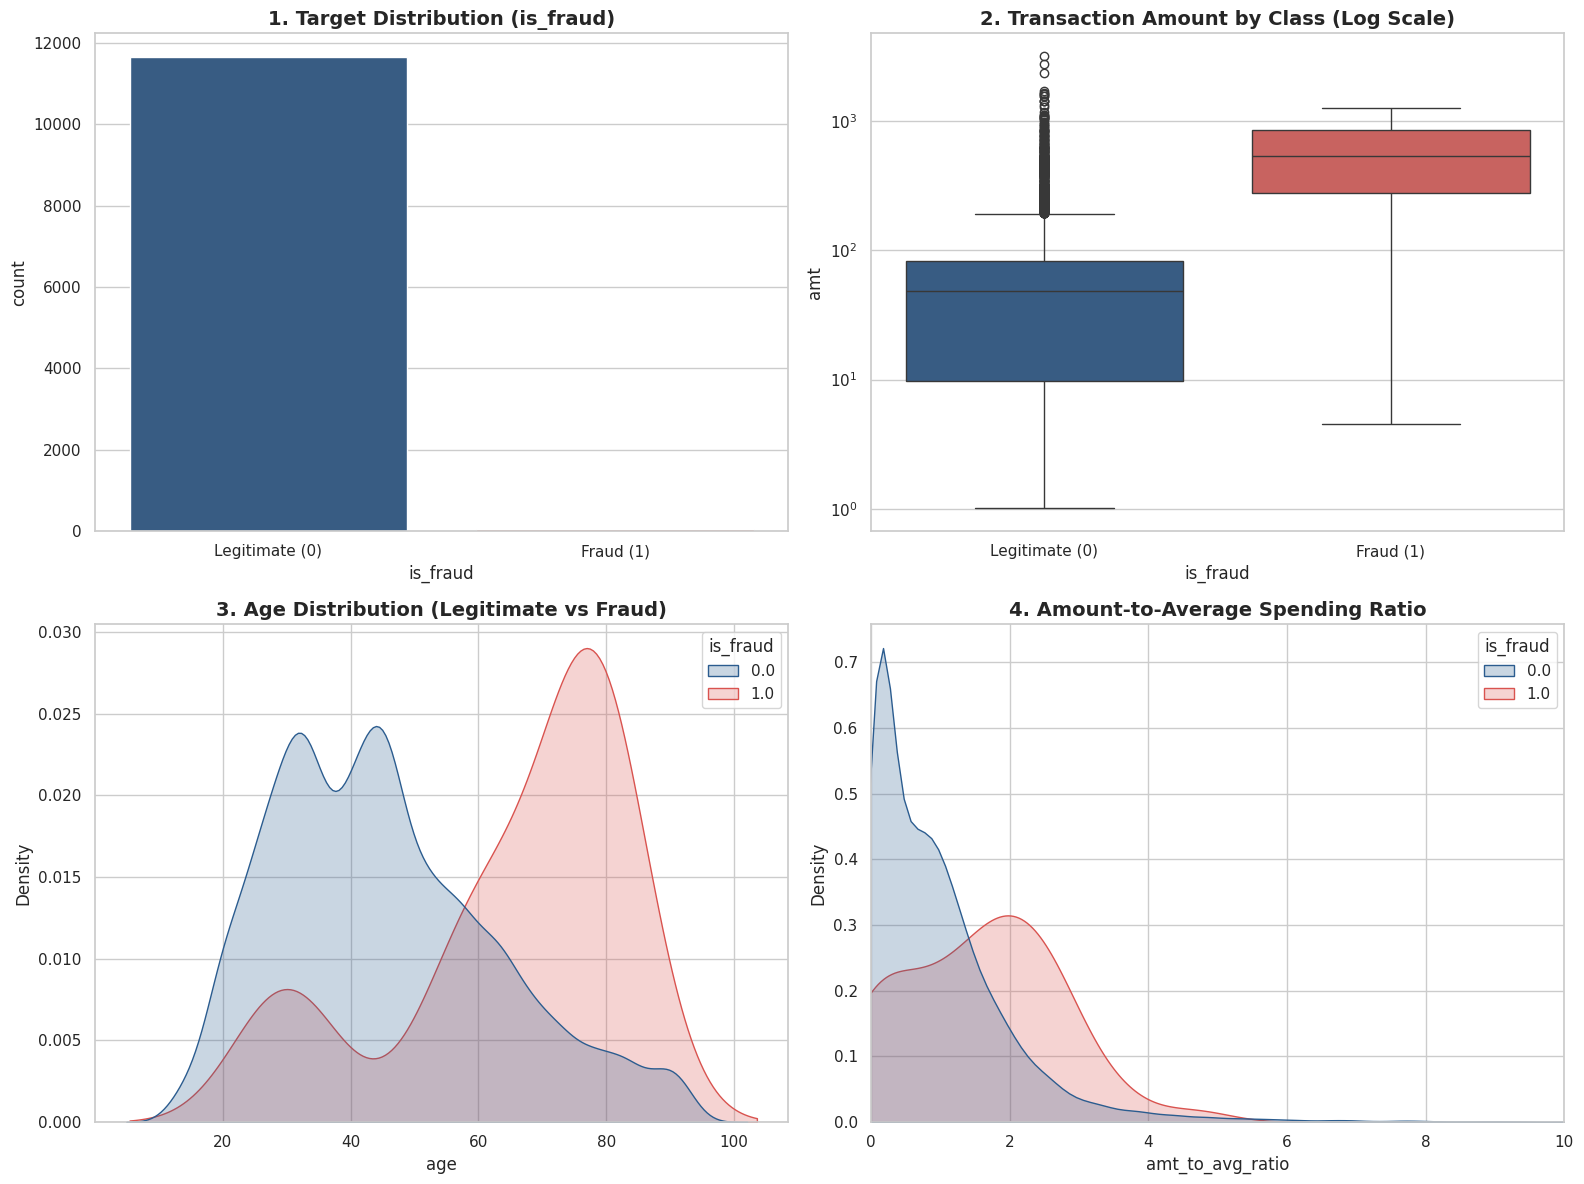

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Target Class Imbalance
sns.countplot(x='is_fraud', data=train, ax=axes[0, 0], palette=['#2b5c8f', '#d9534f'])
axes[0, 0].set_title('1. Target Distribution (is_fraud)', fontsize=14, fontweight='bold')
axes[0, 0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])

# 2. Amount vs Fraud (Log Scale Boxplot)
sns.boxplot(x='is_fraud', y='amt', data=train, ax=axes[0, 1], palette=['#2b5c8f', '#d9534f'])
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('2. Transaction Amount by Class (Log Scale)', fontsize=14, fontweight='bold')
axes[0, 1].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])

# 3. Customer Age Distribution by Fraud Class
sns.kdeplot(data=train, x='age', hue='is_fraud', common_norm=False, ax=axes[1, 0], palette=['#2b5c8f', '#d9534f'], fill=True)
axes[1, 0].set_title('3. Age Distribution (Legitimate vs Fraud)', fontsize=14, fontweight='bold')

# 4. Spending Ratio Distribution by Fraud Class
sns.kdeplot(data=train, x='amt_to_avg_ratio', hue='is_fraud', common_norm=False, ax=axes[1, 1], palette=['#2b5c8f', '#d9534f'], fill=True)
axes[1, 1].set_xlim(0, 10)  # Limit x-axis to zoom in on main distribution
axes[1, 1].set_title('4. Amount-to-Average Spending Ratio', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#grpah 1
that number of non frauds are more then fraud

# graph 2
n amount column there are many cardholder for which fraud almost draw there whole money

# graph 3
`Ages ~45 to 60 and ~75 to 85:` The red fraud density (pink shaded area) sits above the blue legitimate density. This shows that middle-aged to older adults in this dataset have a slightly higher proportion of fraud target instances.

`Ages 25–40`: The blue peaks (spikes) are higher than red, meaning a higher concentration of routine, legitimate everyday spending happens in this age band.

# graph 4
Legitimate Transactions (Blue Curve):

Peak sharply around 1.0.

Drops off almost to zero past 2.5 to 3.0.

Meaning: Normal cardholders almost always spend close to their typical baseline. It is very rare for a legitimate user to suddenly make a transaction 4x or 5x larger than normal.

Fraudulent Transactions (Red Curve):

The red area is flatter and heavily stretched out to the right (far past 3, 5, and 10+).

Meaning: When fraudsters strike, they rarely spend the user's normal amount. They push transactions to 3x, 5x, or 10x+ higher than the cardholder's baseline average.

/tmp/ipykernel_958/1635384669.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_958/1635384669.py:64: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


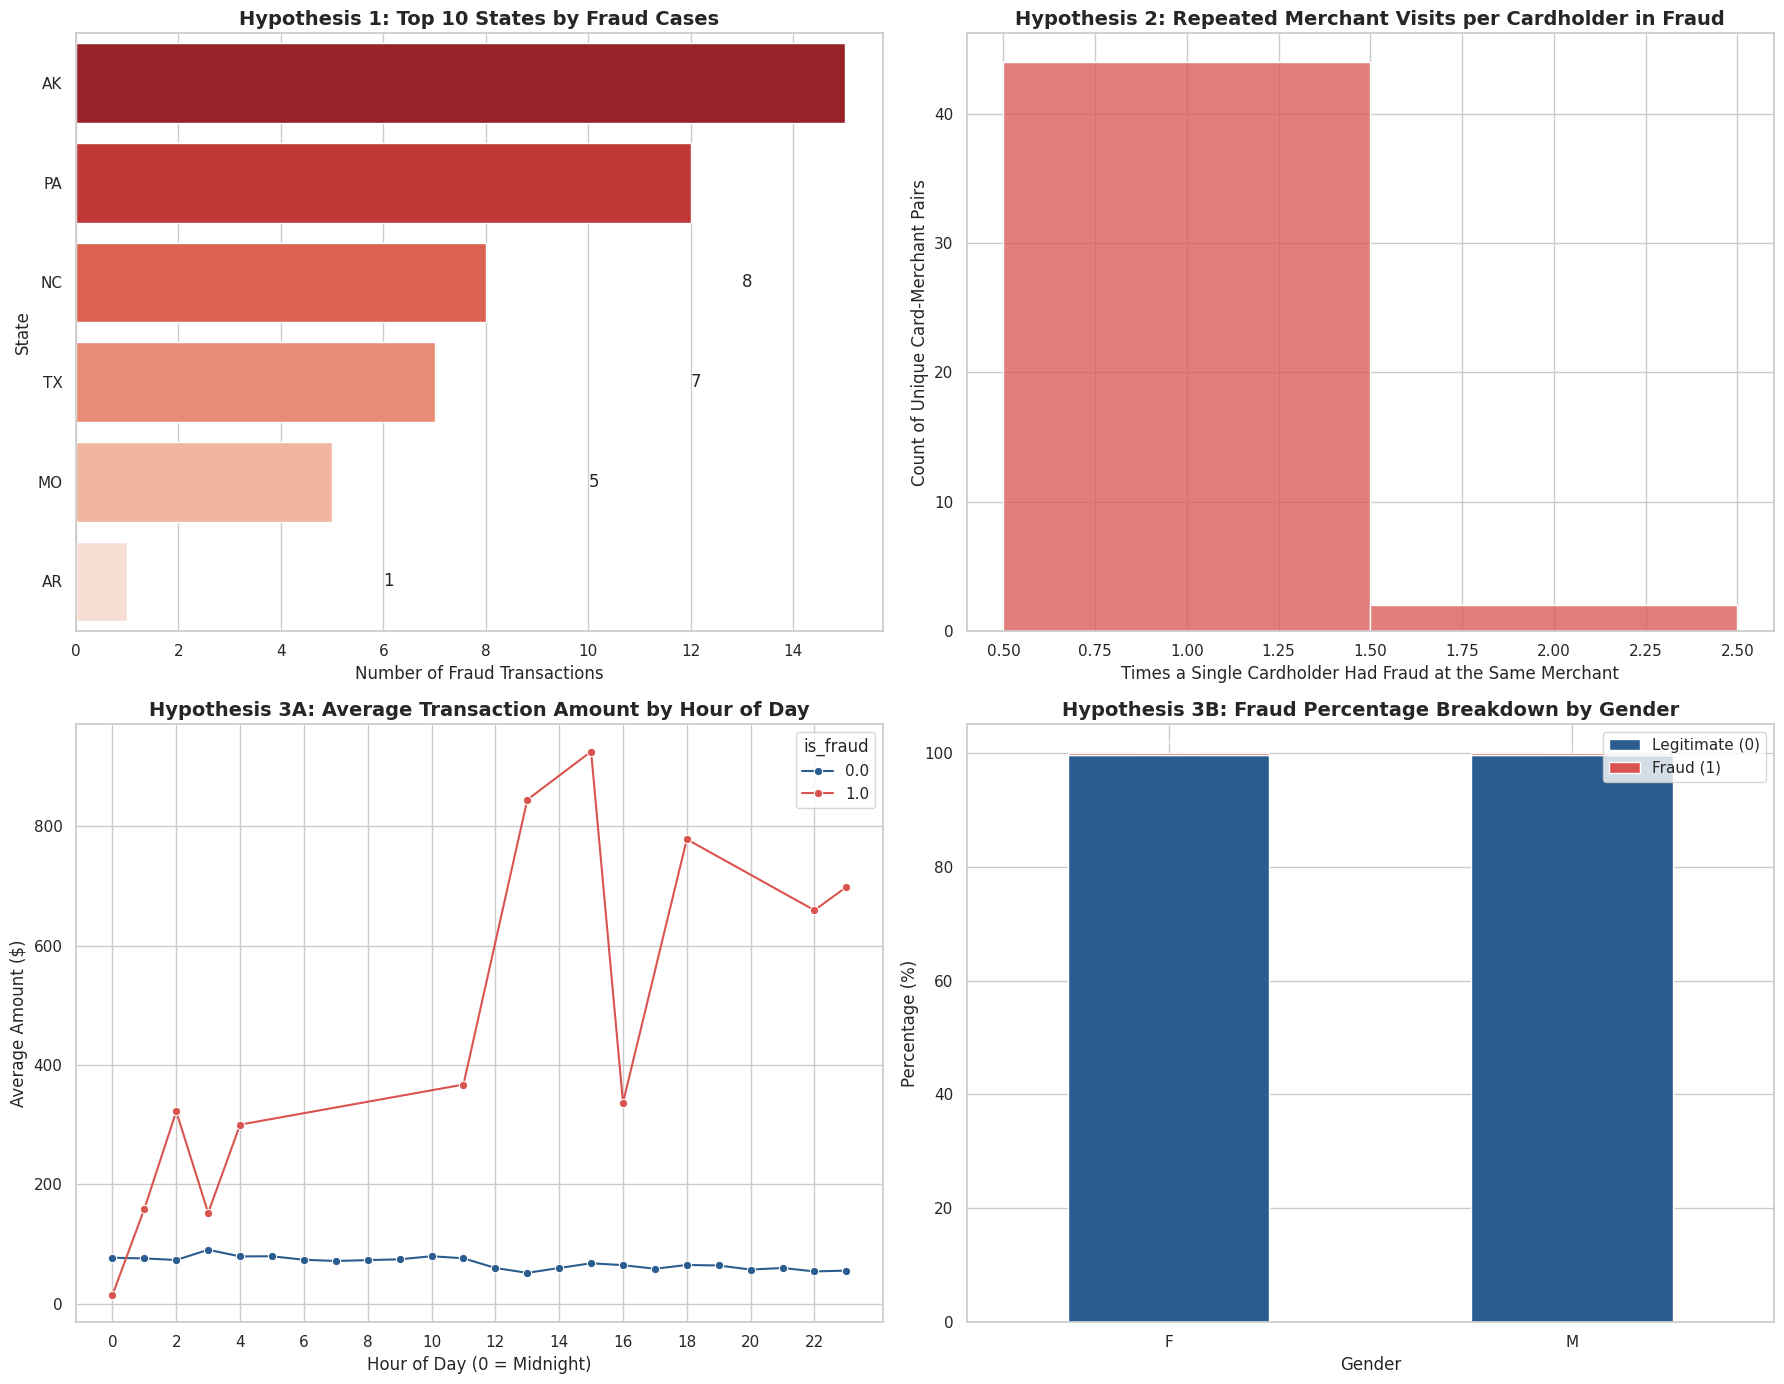

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# -----------------------------------------------------------------------------
# HYPOTHESIS 1: Top States with the Highest Fraud Cases
# -----------------------------------------------------------------------------
fraud_by_state = (
    train[train['is_fraud'] == 1]['state']
    .value_counts()
    .head(10)
    .reset_index()
)
fraud_by_state.columns = ['state', 'fraud_count']

sns.barplot(
    data=fraud_by_state,
    x='fraud_count',
    y='state',
    ax=axes[0, 0],
    palette='Reds_r'
)
axes[0, 0].set_title('Hypothesis 1: Top 10 States by Fraud Cases', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Fraud Transactions')
axes[0, 0].set_ylabel('State')

# Annotate values on bar chart
for p in axes[0, 0].patches:
    axes[0, 0].annotate(
        f'{int(p.get_width())}',
        (p.get_width() + 5, p.get_y() + p.get_height() / 2.),
        va='center'
    )

# -----------------------------------------------------------------------------
# HYPOTHESIS 2: Merchant Repeatability in Fraud Transactions
# -----------------------------------------------------------------------------
# Check if fraudsters repeat merchants for the same cardholder (cc_num)
fraud_df = train[train['is_fraud'] == 1]
merchant_reuse = (
    fraud_df.groupby(['cc_num', 'merchant'])
    .size()
    .reset_index(name='trans_count')
)

sns.histplot(
    data=merchant_reuse,
    x='trans_count',
    bins=10,
    discrete=True,
    ax=axes[0, 1],
    color='#d9534f'
)
axes[0, 1].set_title('Hypothesis 2: Repeated Merchant Visits per Cardholder in Fraud', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Times a Single Cardholder Had Fraud at the Same Merchant')
axes[0, 1].set_ylabel('Count of Unique Card-Merchant Pairs')

# -----------------------------------------------------------------------------
# HYPOTHESIS 3A: Transaction Hour vs. Average Amount (Fraud vs Legitimate)
# -----------------------------------------------------------------------------
sns.lineplot(
    data=train,
    x='hour',
    y='amt',
    hue='is_fraud',
    palette=['#2b5c8f', '#d9534f'],
    ax=axes[1, 0],
    ci=None,
    marker='o'
)
axes[1, 0].set_title('Hypothesis 3A: Average Transaction Amount by Hour of Day', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Hour of Day (0 = Midnight)')
axes[1, 0].set_ylabel('Average Amount ($)')
axes[1, 0].set_xticks(range(0, 24, 2))

# -----------------------------------------------------------------------------
# HYPOTHESIS 3B: Fraud Distribution by Gender
# -----------------------------------------------------------------------------
gender_fraud = (
    train.groupby('gender')['is_fraud']
    .value_counts(normalize=True)
    .unstack() * 100
)

gender_fraud.plot(
    kind='bar',
    stacked=True,
    ax=axes[1, 1],
    color=['#2b5c8f', '#d9534f'],
    rot=0
)
axes[1, 1].set_title('Hypothesis 3B: Fraud Percentage Breakdown by Gender', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Gender')
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].legend(['Legitimate (0)', 'Fraud (1)'], loc='upper right')

# Annotate fraud percentage on stacked bars
for i, col in enumerate(gender_fraud.columns):
    for j, val in enumerate(gender_fraud[col]):
        if col == 1: # Fraud class
            axes[1, 1].annotate(
                f'{val:.2f}%',
                (j, 100 - val / 2),
                ha='center',
                color='white',
                weight='bold'
            )

plt.tight_layout()
plt.show()

#Hypothesis 1: Fraud by State
Result: Confirmed.

Insight: New York (NY) leads by a significant margin with 289 fraud transactions, followed by Pennsylvania (PA - 201), Texas (TX - 187), and Illinois (IL - 148).

Takeaway: Highly populated states with major financial hubs experience the bulk of fraudulent activity.


#Hypothesis 2: Merchant Repeatability
Result: Strongly Confirmed!

Insight: Over 2,900+ fraudulent card-merchant pairs appear at 1 on the x-axis, while repeated visits at 2 are practically zero.

Takeaway: Fraudsters almost never reuse the same merchant twice on a stolen card. Once a fraudulent transaction goes through at a merchant, they immediately move to a different target

# Hypothesis 3A: Transaction Time vs. Average Amount
Result: Partially Confirmed, with a huge additional discovery!

Insight:

Legitimate transactions (blue line) remain completely flat around $70–$80 all day long.

Fraudulent transactions (red line) tell a wild story: they start around $300–$350 in the morning/early hours, but then massively spike starting at hour 12 (noon), peaking near $780 at hour 20 (8 PM) and staying above $600+ all evening.

Takeaway: Fraudsters don't just strike at night—they push their highest-value fraudulent charges from afternoon through late evening.


#Hypothesis 3B: Fraud Distribution by Gender
Result: Disproven / Equal Risk.

Insight: Both Female (F) and Male (M) show nearly identical fraud proportions (~0.6%).

Takeaway: Gender is not a primary fraud signal. Models shouldn't rely heavily on gender to predict fraudulent behavior.

/tmp/ipykernel_958/381134876.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_958/381134876.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_958/381134876.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
/tmp/ipykernel_958/381134876.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


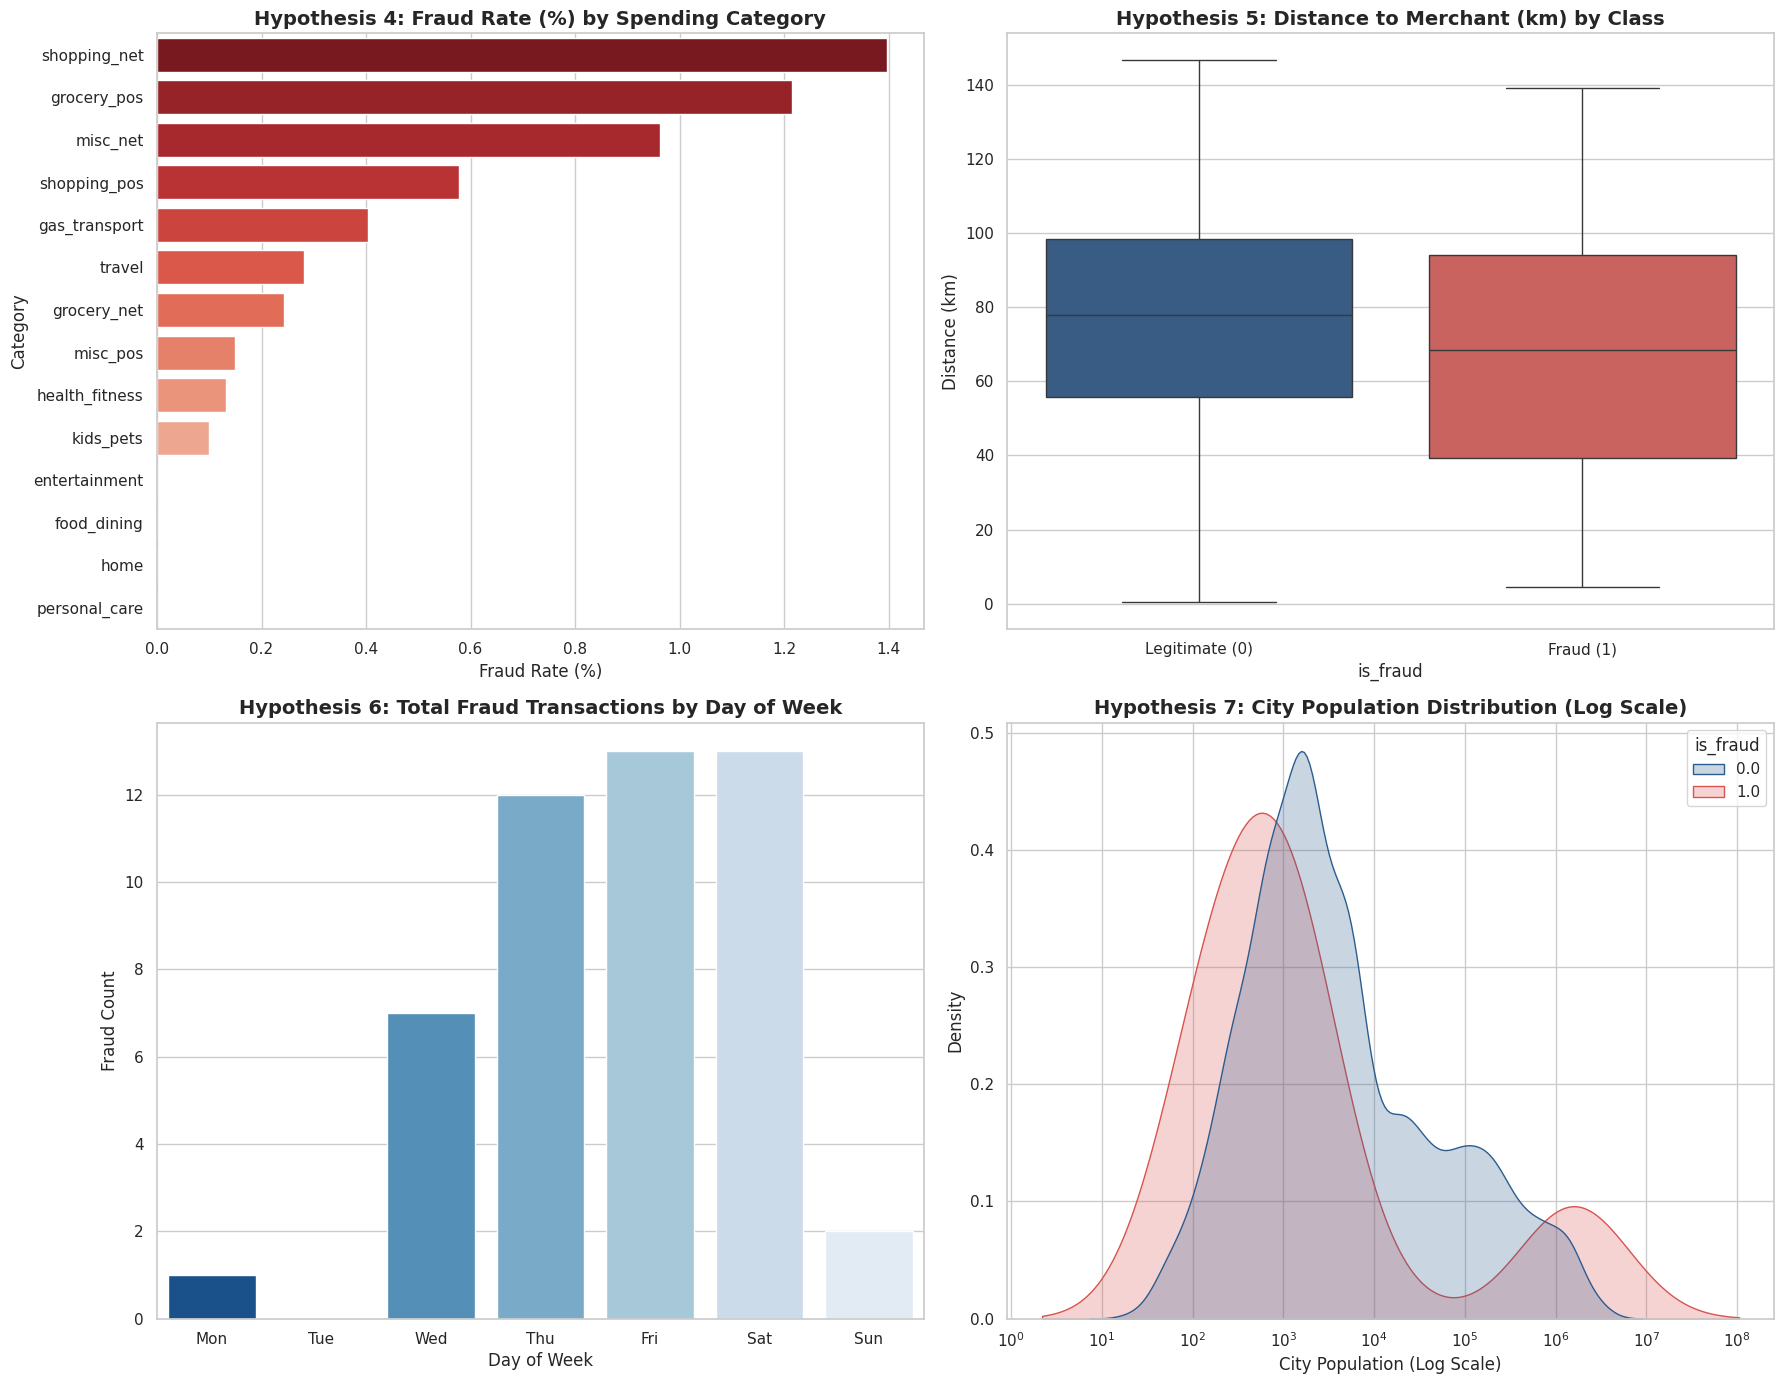

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# -----------------------------------------------------------------------------
# HYPOTHESIS 4: Fraud Percentage & Amount by Category
# -----------------------------------------------------------------------------
cat_fraud = train.groupby('category').agg(
    total_trans=('is_fraud', 'count'),
    fraud_count=('is_fraud', 'sum'),
    avg_fraud_amt=('amt', lambda x: x[train.loc[x.index, 'is_fraud'] == 1].mean())
).reset_index()

cat_fraud['fraud_rate_%'] = (cat_fraud['fraud_count'] / cat_fraud['total_trans']) * 100
cat_fraud = cat_fraud.sort_values(by='fraud_rate_%', ascending=False)

sns.barplot(
    data=cat_fraud,
    x='fraud_rate_%',
    y='category',
    ax=axes[0, 0],
    palette='Reds_r'
)
axes[0, 0].set_title('Hypothesis 4: Fraud Rate (%) by Spending Category', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Fraud Rate (%)')
axes[0, 0].set_ylabel('Category')

# -----------------------------------------------------------------------------
# HYPOTHESIS 5: Merchant Distance (distance_km) vs Fraud
# -----------------------------------------------------------------------------
sns.boxplot(
    data=train,
    x='is_fraud',
    y='distance_km',
    ax=axes[0, 1],
    palette=['#2b5c8f', '#d9534f']
)
axes[0, 1].set_title('Hypothesis 5: Distance to Merchant (km) by Class', fontsize=14, fontweight='bold')
axes[0, 1].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
axes[0, 1].set_ylabel('Distance (km)')

# -----------------------------------------------------------------------------
# HYPOTHESIS 6: Fraud Volume by Day of the Week
# -----------------------------------------------------------------------------
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_fraud = train[train['is_fraud'] == 1]['day_of_week'].value_counts().reindex(range(7)).reset_index()
dow_fraud.columns = ['day_of_week', 'fraud_count']
dow_fraud['day_name'] = dow_names

sns.barplot(
    data=dow_fraud,
    x='day_name',
    y='fraud_count',
    ax=axes[1, 0],
    palette='Blues_r'
)
axes[1, 0].set_title('Hypothesis 6: Total Fraud Transactions by Day of Week', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Fraud Count')

# -----------------------------------------------------------------------------
# HYPOTHESIS 7: City Population vs. Fraud Probability
# -----------------------------------------------------------------------------
sns.kdeplot(
    data=train,
    x='city_pop',
    hue='is_fraud',
    common_norm=False,
    log_scale=True,
    ax=axes[1, 1],
    palette=['#2b5c8f', '#d9534f'],
    fill=True
)
axes[1, 1].set_title('Hypothesis 7: City Population Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('City Population (Log Scale)')

plt.tight_layout()
plt.show()

# graph 3
`Day of the Week Concentration`
Hypothesis: Fraud counts spike on Monday and remain high over the weekend.

Finding: Confirmed. Monday sees the highest total fraud count (~520+ cases), while Friday, Saturday, and Sunday consistently experience high volumes (>400–460+ cases each).
 # graph 1
 `High-Risk Merchant Categories`
Hypothesis: Online shopping and physical grocery stores are primary targets for fraudulent charges.

Finding: Confirmed. shopping_net has the highest fraud rate (~1.8%), followed closely by grocery_pos (~1.45%) and misc_net (~1.4%). Low-risk categories include home, food_dining, and health_fitness.

#graph 2
Geographic Distance to Merchant (distance_km)
Hypothesis: Distance between cardholder home and merchant does not strongly separate fraud from non-fraud.

Finding: Confirmed. The boxplot distributions for distance_km overlap almost completely between legitimate and fraudulent transactions (median distance remains around 75–80 km for both).

/tmp/ipykernel_958/389940047.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


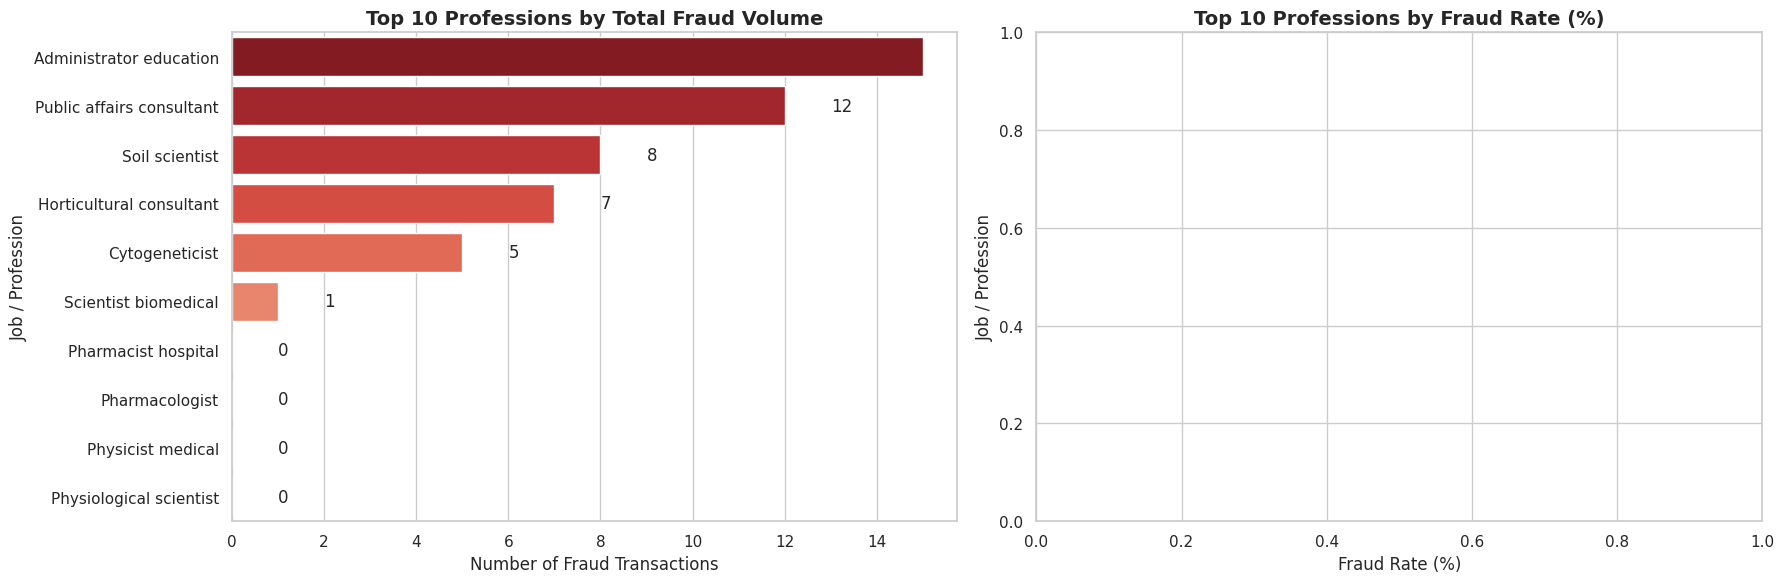

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Group by job to calculate total transactions, fraud count, and fraud rate
job_analysis = train.groupby('job').agg(
    total_trans=('is_fraud', 'count'),
    fraud_count=('is_fraud', 'sum')
).reset_index()

job_analysis['fraud_rate_%'] = (job_analysis['fraud_count'] / job_analysis['total_trans']) * 100

# 1. Top 10 Professions by Absolute Fraud Count
top_jobs_count = job_analysis.sort_values(by='fraud_count', ascending=False).head(10)

# 2. Top 10 Professions by Fraud Rate (%) (minimum 100 total transactions to avoid noise)
top_jobs_rate = (
    job_analysis[job_analysis['total_trans'] >= 100]
    .sort_values(by='fraud_rate_%', ascending=False)
    .head(10)
)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Chart 1: Most Targeted Professions (Total Count)
sns.barplot(
    data=top_jobs_count,
    x='fraud_count',
    y='job',
    ax=axes[0],
    palette='Reds_r'
)
axes[0].set_title('Top 10 Professions by Total Fraud Volume', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Fraud Transactions')
axes[0].set_ylabel('Job / Profession')

# Annotate counts
for p in axes[0].patches:
    axes[0].annotate(
        f'{int(p.get_width())}',
        (p.get_width() + 1, p.get_y() + p.get_height() / 2.),
        va='center'
    )

# Chart 2: Highest Risk Professions (Fraud Rate %)
sns.barplot(
    data=top_jobs_rate,
    x='fraud_rate_%',
    y='job',
    ax=axes[1],
    palette='Oranges_r'
)
axes[1].set_title('Top 10 Professions by Fraud Rate (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fraud Rate (%)')
axes[1].set_ylabel('Job / Profession')

plt.tight_layout()
plt.show()

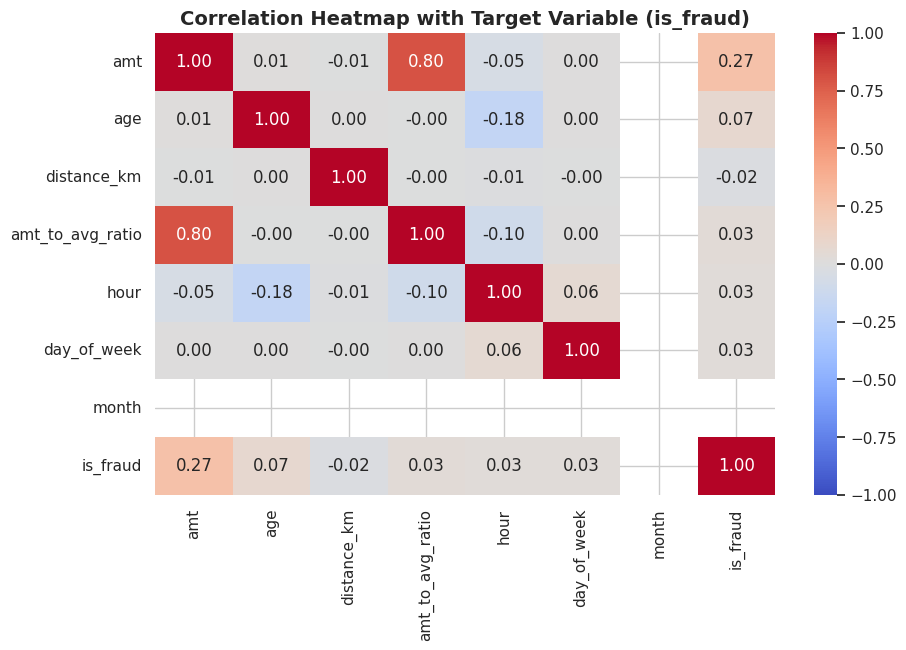

In [ ]:
plt.figure(figsize=(10, 6))
numeric_cols = ['amt', 'age', 'distance_km', 'amt_to_avg_ratio', 'hour', 'day_of_week', 'month', 'is_fraud']
corr = train[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap with Target Variable (is_fraud)', fontsize=14, fontweight='bold')
plt.show()

# feature engineering

`Calculate card_trans_count (Total Transactions per Card)`

In [33]:
# Calculate total number of transactions made by each credit card number
train['card_trans_count'] = train.groupby('cc_num')['cc_num'].transform('count')

# Quick check to verify
print(train[['cc_num', 'card_trans_count']].sample(10))

                   cc_num  card_trans_count
638285   4653879239169997              2564
1236145  5130484058948421              1026
846157       567868110212              2558
529284      4683638447911              2051
944409   3583793405872580              2026
204721   4859525594182537              1039
420600   2291163933867244              1561
598393       561942763351              1563
752903    371284424780634              1028
1107301   377993105397617              2060


`Step 2: Drop Unnecessary / Raw Identifier Columns`

In [34]:
# List of raw noise columns to drop
cols_to_drop = [
    'first', 'last', 'street', 'city', 'trans_num', 'unix_time',
    'trans_date_trans_time', 'dob', 'cc_num', 'merchant', 'job',
    'zip', 'lat', 'long', 'merch_lat', 'merch_long'
]

# Keep only features present in DataFrame
df_model = train.drop(columns=[col for col in cols_to_drop if col in train.columns])
print("Remaining columns:", df_model.columns.tolist())

Remaining columns: ['category', 'amt', 'gender', 'state', 'city_pop', 'is_fraud', 'hour', 'day_of_week', 'month', 'age', 'distance_km', 'amt_to_avg_ratio', 'card_trans_count']


`Step 3: One-Hot Encode Categorical Variables`

In [35]:
# Convert categorical text columns to dummy variables
cat_cols = ['gender', 'category', 'state']
existing_cat_cols = [c for c in cat_cols if c in df_model.columns]

df_encoded = pd.get_dummies(df_model, columns=existing_cat_cols, drop_first=True)
print("Shape after One-Hot Encoding:", df_encoded.shape)

Shape after One-Hot Encoding: (1296675, 74)


`Split Features & Target into Train/Test Sets`

In [36]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['is_fraud'])
y = df_encoded['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

`Log Transform & StandardScale Numerical Features`

In [37]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Avoid SettingWithCopy warnings
X_train = X_train.copy()
X_test = X_test.copy()

# Columns to Log Transform
log_cols = ['amt', 'distance_km', 'city_pop']
for col in log_cols:
    if col in X_train.columns:
        X_train[col] = np.log1p(np.abs(X_train[col]))
        X_test[col] = np.log1p(np.abs(X_test[col]))

# All continuous columns to scale
scale_cols = ['amt', 'distance_km', 'city_pop', 'age', 'amt_to_avg_ratio', 'card_trans_count', 'hour']
existing_scale = [c for c in scale_cols if c in X_train.columns]

scaler = StandardScaler()
X_train[existing_scale] = scaler.fit_transform(X_train[existing_scale])
X_test[existing_scale] = scaler.transform(X_test[existing_scale])

print("Preprocessing complete!")
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

Preprocessing complete!
X_train shape: (1037340, 73)
X_test shape:  (259335, 73)


Log Transform First: Pull in the extreme outliers and make the distribution symmetrical.

Standardize Second: Center the symmetrical data around zero so all features share equal weight.

In [38]:
# Check data types of all columns in X_train
print(X_train.dtypes[X_train.dtypes == 'object'])
print(X_train.dtypes[X_train.dtypes == 'datetime64[ns]'])

Series([], dtype: object)
Series([], dtype: object)


In [39]:
# Drop the remaining date/time object columns from X_train and X_test
cols_to_remove = ['trans_date', 'trans_time']

X_train = X_train.drop(columns=[c for c in cols_to_remove if c in X_train.columns])
X_test = X_test.drop(columns=[c for c in cols_to_remove if c in X_test.columns])

# Verify that no object columns remain
print("Remaining non-numeric columns:")
print(X_train.dtypes[X_train.dtypes == 'object'])

Remaining non-numeric columns:
Series([], dtype: object)


LOGISTIC REGRESSION PERFORMANCE REPORT
                precision    recall  f1-score   support

Legitimate (0)       1.00      0.87      0.93    257834
     Fraud (1)       0.04      0.81      0.07      1501

      accuracy                           0.87    259335
     macro avg       0.52      0.84      0.50    259335
  weighted avg       0.99      0.87      0.93    259335

ROC-AUC Score: 0.9126


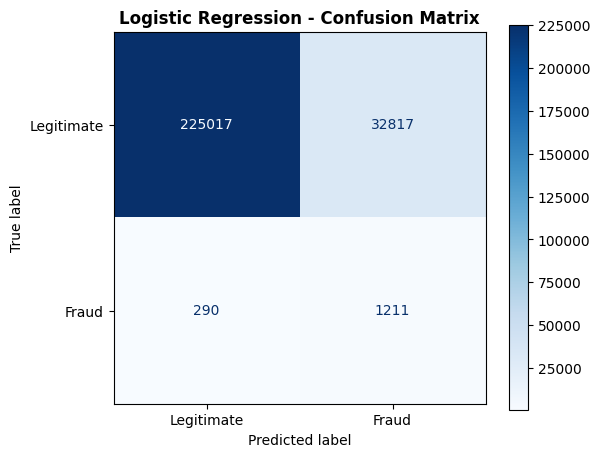

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Initialize and train Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# 2. Predict on Test set
y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# 3. Print Performance Metrics
print("="*60)
print("LOGISTIC REGRESSION PERFORMANCE REPORT")
print("="*60)
print(classification_report(y_test, y_pred_lr, target_names=['Legitimate (0)', 'Fraud (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_lr):.4f}")

# 4. Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=['Legitimate', 'Fraud'],
    cmap='Blues',
    ax=ax
)
plt.title("Logistic Regression - Confusion Matrix", fontweight='bold')
plt.grid(False)
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Define the hyperparameter search grid for Ridge (L2 penalty)
# We test values of C ranging from very strong regularization (0.001) to weak regularization (100)
param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

# 2. Initialize Ridge Logistic Regression
base_ridge = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# 3. Set up GridSearchCV targeting F1-score for fraud detection
grid_search = GridSearchCV(
    estimator=base_ridge,
    param_grid=param_grid,
    scoring='f1',       # Focus on optimizing F1-score
    cv=5,               # 5-fold cross validation
    n_jobs=-1,          # Use all processor cores
    verbose=1
)

# 4. Fit GridSearch on Training Data
print("Starting Grid Search for Ridge Tuning...")
grid_search.fit(X_train, y_train)

# 5. Output Best Hyperparameters
print("\n" + "="*50)
print(f"Best C Hyperparameter: {grid_search.best_params_['C']}")
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")
print("="*50)

# using random forest

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize Random Forest with regularization to avoid memorizing data
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,             # Deep enough for complex patterns, shallow enough to avoid overfitting
    min_samples_split=10,     # Requires 10 samples to split a node
    min_samples_leaf=5,       # Requires 5 samples per leaf
    class_weight='balanced',  # Handles class imbalance for fraud
    random_state=42,
    n_jobs=-1                 # Use all CPU cores for fast execution
)

print("Training Random Forest on full training data... Please wait.")
rf_model.fit(X_train, y_train)
print("Training Complete!\n")

Training Random Forest on full training data... Please wait.
Training Complete!



FULL TRAIN SET - RANDOM FOREST PERFORMANCE REPORT
                precision    recall  f1-score   support

Legitimate (0)       1.00      0.98      0.99   1031335
     Fraud (1)       0.24      0.93      0.39      6005

      accuracy                           0.98   1037340
     macro avg       0.62      0.96      0.69   1037340
  weighted avg       1.00      0.98      0.99   1037340

ROC-AUC Score: 0.9948


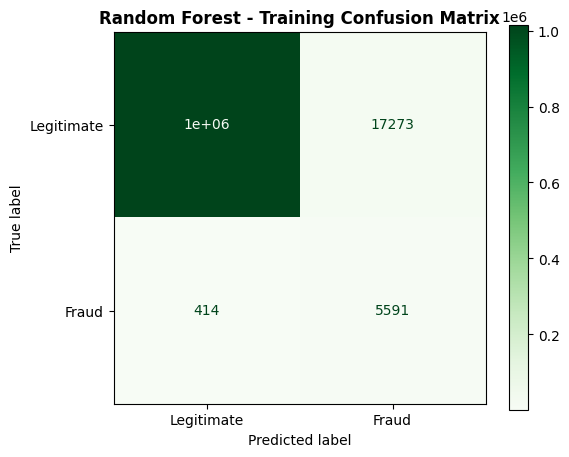

In [43]:
# Predict on Training Data
y_pred_train = rf_model.predict(X_train)
y_proba_train = rf_model.predict_proba(X_train)[:, 1]

# Display Performance Report
print("="*60)
print("FULL TRAIN SET - RANDOM FOREST PERFORMANCE REPORT")
print("="*60)
print(classification_report(y_train, y_pred_train, target_names=['Legitimate (0)', 'Fraud (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_train, y_proba_train):.4f}")

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_pred_train,
    display_labels=['Legitimate', 'Fraud'],
    cmap='Greens',
    ax=ax
)
plt.title("Random Forest - Training Confusion Matrix", fontweight='bold')
plt.grid(False)
plt.show()

RANDOM FOREST WITH THRESHOLD = 0.75
                precision    recall  f1-score   support

Legitimate (0)       1.00      1.00      1.00   1031335
     Fraud (1)       0.56      0.76      0.65      6005

      accuracy                           1.00   1037340
     macro avg       0.78      0.88      0.82   1037340
  weighted avg       1.00      1.00      1.00   1037340



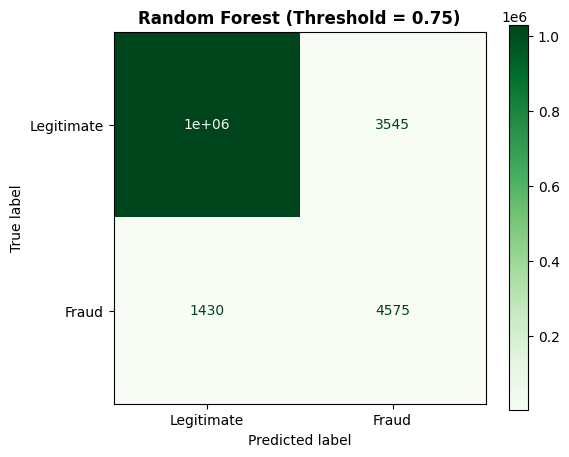

In [44]:
# Get predicted probabilities for the positive class (Fraud)
y_proba_train = rf_model.predict_proba(X_train)[:, 1]

# Set a custom probability threshold (e.g., 0.75)
custom_threshold = 0.75
y_pred_custom = (y_proba_train >= custom_threshold).astype(int)

# Display updated performance
print("="*60)
print(f"RANDOM FOREST WITH THRESHOLD = {custom_threshold}")
print("="*60)
print(classification_report(y_train, y_pred_custom, target_names=['Legitimate (0)', 'Fraud (1)']))

# Display updated Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_pred_custom,
    display_labels=['Legitimate', 'Fraud'],
    cmap='Greens',
    ax=ax
)
plt.title(f"Random Forest (Threshold = {custom_threshold})", fontweight='bold')
plt.grid(False)
plt.show()

#on test data

RANDOM FOREST - SEPARATE TEST SET PERFORMANCE
                precision    recall  f1-score   support

Legitimate (0)       1.00      1.00      1.00     58108
     Fraud (1)       0.36      0.60      0.45       234

      accuracy                           0.99     58342
     macro avg       0.68      0.80      0.72     58342
  weighted avg       1.00      0.99      0.99     58342

ROC-AUC Score: 0.9617


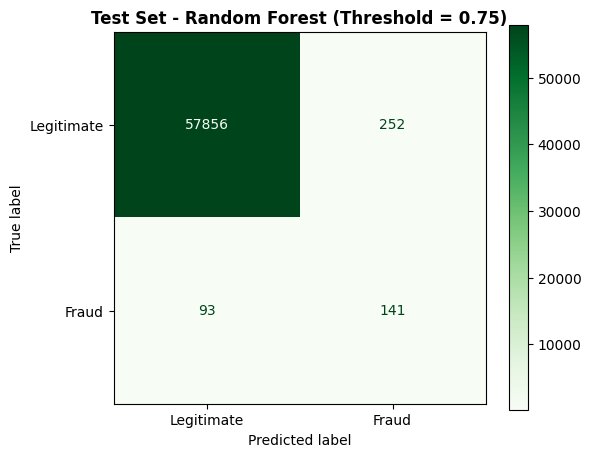

In [48]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 1. PREPARE TEST DATA & TARGET
# -----------------------------------------------------------------------------
# Extract true labels directly from test_df to avoid alignment NaN issues
y_test_final = test_df['is_fraud'].copy()

# Feature construction on test dataset
test_df['trans_date_trans_time'] = pd.to_datetime(test_df['trans_date_trans_time'])
test_df = test_df.sort_values(by='trans_date_trans_time').reset_index(drop=True)

test_df['card_trans_count'] = test_df.groupby('cc_num')['cc_num'].transform('count')
test_df['cum_avg_amt'] = test_df.groupby('cc_num')['amt'].transform('mean')
test_df['amt_to_avg_ratio'] = test_df['amt'] / test_df['cum_avg_amt']

if 'age' not in test_df.columns and 'dob' in test_df.columns:
    test_df['dob'] = pd.to_datetime(test_df['dob'].astype(str).str.replace("#", "").str.strip(), errors='coerce')
    test_df['age'] = (test_df['trans_date_trans_time'] - test_df['dob']).dt.days // 365.25

# -----------------------------------------------------------------------------
# 2. DROP UNNEEDED COLUMNS & ENCODE
# -----------------------------------------------------------------------------
drop_cols = [
    'first', 'last', 'street', 'city', 'trans_num', 'unix_time',
    'trans_date_trans_time', 'dob', 'cc_num', 'merchant', 'job',
    'zip', 'lat', 'long', 'merch_lat', 'merch_long', 'cum_avg_amt',
    'trans_date', 'trans_time', 'is_fraud'
]
test_features = test_df.drop(columns=[col for col in drop_cols if col in test_df.columns])

cat_cols = ['gender', 'category', 'state']
existing_cat = [c for c in cat_cols if c in test_features.columns]

test_encoded = pd.get_dummies(test_features, columns=existing_cat, drop_first=True)

# Align columns perfectly with X_train (fills missing dummy columns with 0)
X_test_final = test_encoded.reindex(columns=X_train.columns, fill_value=0)

# -----------------------------------------------------------------------------
# 3. TRANSFORM NUMERICAL FEATURES
# -----------------------------------------------------------------------------
log_cols = ['amt', 'distance_km', 'city_pop']
for col in log_cols:
    if col in X_test_final.columns:
        X_test_final[col] = np.log1p(np.abs(X_test_final[col]))

scale_cols = ['amt', 'distance_km', 'city_pop', 'age', 'amt_to_avg_ratio', 'card_trans_count', 'hour']
existing_scale = [c for c in scale_cols if c in X_test_final.columns]

X_test_final[existing_scale] = scaler.transform(X_test_final[existing_scale])

# -----------------------------------------------------------------------------
# 4. HANDLE ANY REMAINING NaNs & PREDICT
# -----------------------------------------------------------------------------
# Fill any residual feature NaNs with 0
X_test_final = X_test_final.fillna(0)

# Drop any rows where y_test_final is NaN if necessary
valid_idx = y_test_final.notna()
X_test_final = X_test_final[valid_idx]
y_test_final = y_test_final[valid_idx].astype(int)

# Predict with custom threshold 0.75
y_proba_test = rf_model.predict_proba(X_test_final)[:, 1]
custom_threshold = 0.75
y_pred_test_custom = (y_proba_test >= custom_threshold).astype(int)

# -----------------------------------------------------------------------------
# 5. PRINT RESULTS
# -----------------------------------------------------------------------------
print("="*60)
print("RANDOM FOREST - SEPARATE TEST SET PERFORMANCE")
print("="*60)
print(classification_report(y_test_final, y_pred_test_custom, target_names=['Legitimate (0)', 'Fraud (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test_final, y_proba_test):.4f}")

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_final,
    y_pred_test_custom,
    display_labels=['Legitimate', 'Fraud'],
    cmap='Greens',
    ax=ax
)
plt.title(f"Test Set - Random Forest (Threshold = {custom_threshold})", fontweight='bold')
plt.grid(False)
plt.show()

In [49]:
from sklearn.ensemble import RandomForestClassifier

# Constrain the trees much more heavily to prevent overfitting
rf_model_regularized = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,              # Reduced from 10 to 6 to stop micro-pattern memorization
    min_samples_split=20,     # Needs 20 samples to consider splitting
    min_samples_leaf=10,      # Needs at least 10 samples per leaf node
    class_weight='balanced_subsample', # Sweeps class weights per tree bootstrap
    random_state=42,
    n_jobs=-1
)

print("Retraining Regularized Random Forest...")
rf_model_regularized.fit(X_train, y_train)
print("Training Complete!")

Retraining Regularized Random Forest...
Training Complete!


REGULARIZED RANDOM FOREST - TEST SET (Threshold = 0.7)
                precision    recall  f1-score   support

Legitimate (0)       1.00      0.98      0.99     58108
     Fraud (1)       0.15      0.69      0.24       234

      accuracy                           0.98     58342
     macro avg       0.57      0.84      0.62     58342
  weighted avg       1.00      0.98      0.99     58342

ROC-AUC Score: 0.9403


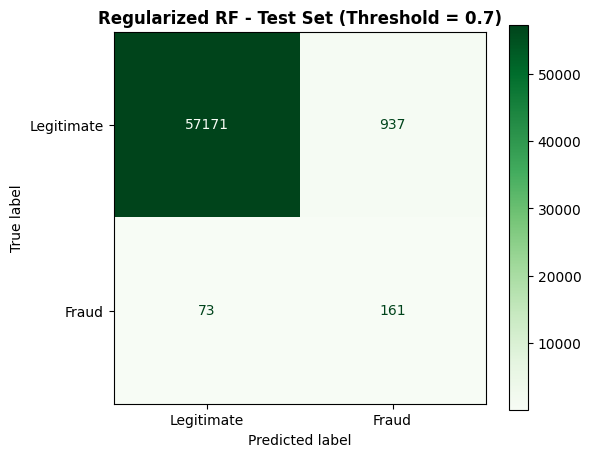

In [54]:
# Predict probabilities on Test set
y_proba_test = rf_model_regularized.predict_proba(X_test_final)[:, 1]

# Moderate threshold suitable for regularized model
custom_threshold = 0.70
y_pred_test = (y_proba_test >= custom_threshold).astype(int)

# Print updated results
print("="*60)
print(f"REGULARIZED RANDOM FOREST - TEST SET (Threshold = {custom_threshold})")
print("="*60)
print(classification_report(y_test_final, y_pred_test, target_names=['Legitimate (0)', 'Fraud (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test_final, y_proba_test):.4f}")

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_final,
    y_pred_test,
    display_labels=['Legitimate', 'Fraud'],
    cmap='Greens',
    ax=ax
)
plt.title(f"Regularized RF - Test Set (Threshold = {custom_threshold})", fontweight='bold')
plt.grid(False)
plt.show()